# DeepSortV5


In [ ]:
# !git clone --recurse-submodules https://github.com/mikel-brostrom/Yolov5_DeepSort_Pytorch.git

In [1]:
# %cd /Users/nguyenduy/Desktop/pcgvs-main/notebooks/Yolov5_DeepSort_Pytorch

/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Yolov5_DeepSort_Pytorch


In [2]:
# ! pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 2.3 MB/s eta 0:00:0000:0100:01
  Using cached gitdb-4.0.9-py3-none-any.whl (63 kB)
  Using cached smmap-5.0.0-py3-none-any.whl (24 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.2
    Uninstalling numpy-1.23.2:
      Successfully uninstalled numpy-1.23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.22.4 which is incompatible.

[notice] A new release of pip available: 22.2.2 -> 22.3
[notice] To update, run: pip install --upgrade pip


#### --class 0 chỉ lấy nhãn là người

In [10]:
# !python track.py --source /Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/Video_input/video4.mp4 --yolo-weights weights/yolov5m.pt --strong-sort-weights osnet_x0_25_msmt17.pt --save-txt --class 0

/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Yolov5_DeepSort_Pytorch/strong_sort/deep/reid/torchreid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
Model: osnet_x0_25
- params: 203,568
- flops: 82,316,000
Successfully loaded pretrained weights from "osnet_x0_25_msmt17.pt"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']


In [ ]:
# !python track.py --source /content/drive/MyDrive/Video/Test6.mp4 --yolo-weights weights/yolov5m.pt --strong-sort-weights osnet_x0_25_msmt17.pt --save-vid --save-txt 

# Input/Output

In [1]:
#input video
# input_vid="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/Video_input/video4.mp4"

#input image patches crop from detection
path="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/patches"

#output video synopsis path
output_vid="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis"

# object txt input from deepsort
input_txt="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/data_input_txt_object/meta.txt"

#input background
input_background="/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/background.png"

# Extract Patches

In order to extract patches from a video, first of all, let's create a dictionary called **frames**, which index are the number of the frame and every record contains a list of object that are in the scene. For an object we have:

- **tag**: unique identifier of the object on stage;
- **x**: position along the x axis;
- **y**: position along the y axis;
- **w**: width of the patch;
- **h**: height of the patch.

In [2]:
frames = {}
frame_id=[]
f1=[0]
count=0

with open("/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/data_input_txt_object/meta.txt", 'r') as f:
    for line in f:
        f= line.split()[22][0:5]
        frame_id.append(f)

    for i in range(0,len(frame_id)-1):
        if (frame_id[i]!=frame_id[i+1]):
            count+=1
            f1.append(count)
        else:
            f1.append(count) 
              
    for i in f1:
        id=line.split()[3][0:5]
        x= line.split()[7][1:-1]
        y=line.split()[8][0:-1]
        w=line.split()[9][0:-1]
        h=line.split()[10][0:-2]

        if int(i) not in frames.keys():
            frames[int(i)] = []
        frames[int(i)].append([id, int(x), int(y), int(w), int(h)])


{169: [['1', 40, 242, 25, 21]],
 170: [['1', 39, 240, 27, 24]],
 171: [['1', 39, 239, 27, 25]],
 174: [['1', 37, 238, 30, 26]],
 175: [['1', 38, 236, 25, 27]],
 176: [['1', 36, 234, 29, 30], ['4', 108, 244, 23, 20]],
 177: [['1', 35, 232, 33, 31], ['4', 109, 244, 24, 20]],
 178: [['1', 34, 231, 34, 33], ['4', 112, 241, 23, 22]],
 179: [['1', 35, 231, 36, 33], ['4', 112, 240, 25, 23]],
 180: [['1', 39, 232, 32, 32], ['4', 113, 238, 25, 25]],
 181: [['1', 42, 231, 30, 33], ['4', 113, 236, 25, 27]],
 182: [['1', 43, 230, 32, 33], ['4', 112, 235, 27, 29]],
 183: [['1', 44, 228, 33, 35], ['4', 111, 235, 26, 29]],
 184: [['1', 37, 225, 44, 38], ['4', 109, 235, 28, 28]],
 185: [['1', 38, 223, 43, 40], ['4', 104, 235, 33, 29]],
 186: [['1', 46, 222, 37, 42], ['4', 101, 232, 39, 32]],
 187: [['1', 47, 222, 38, 42], ['4', 100, 229, 42, 35]],
 188: [['1', 47, 222, 38, 42], ['4', 99, 228, 44, 36]],
 189: [['1', 46, 222, 37, 42], ['4', 99, 227, 44, 37]],
 190: [['1', 40, 220, 44, 43], ['4', 100, 22

The function `extract_patches` take in input the following values:

- **path_tubes**: the path of file that contains the objects' tubes;
- **source**: the path of the video, from which we want to extract the patches;
- **outputdir**: the output folder.

Inside the `ouputdir` you'll find a folder called `patches` that contains all patches, the path of this folder is returned from the function. The name format for files inside `patches` is: `<tag>_<frame>.jpg`.

In [3]:
# from pcgvs.extraction import extract_patches
# extract_patches(
#     path_tubes=input_txt, 
#     source=input_vid, 
#     outputdir=output_vid
# )

4515it [00:08, 510.00it/s]                          


'/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/patches'

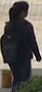

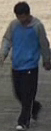

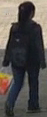

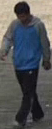

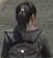

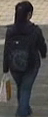

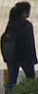

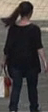

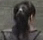

In [4]:
# import glob
# from IPython.display import Image, display
# import random

# images = []
# for imageName in glob.glob('/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/patches/*.png'):
#     images.append(imageName)

# for _ in range(10):
#     display(
#         Image(
#             filename = images[random.randint(0, len(images) - 1)]
#         )
# )

# Extract Background

The function `extract_background` take in input the following values:

- **path_tubes**: the path of file that contains the objects' tubes;
- **source**: the path of the video, from which we want to extract the patches;
- **outputdir**: the output folder.

It returns the path of the `background.jpg`.

In [5]:
# from pcgvs.extraction import extract_background

# extract_background(
#     path_tubes=input_txt, 
#     source=input_vid, 
#     outputdir=output_vid
# )

extracting background | frame 2
extracting background | frame 3
extracting background | frame 4
extracting background | frame 5
extracting background | frame 6
extracting background | frame 7
extracting background | frame 8
extracting background | frame 9
extracting background | frame 10
extracting background | frame 11
extracting background | frame 12
extracting background | frame 13


'/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/background.png'

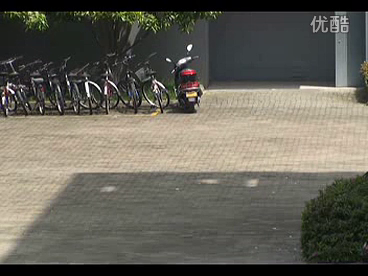

In [6]:
display(Image(filename = input_background))

# Tube rearrangement

Import the output file from the **tube extraction** stage:

In [7]:
from os import path, getcwd
from pcgvs.extraction import load_tubes_with_pandas

# Generating an OS safe path.
p = path.join(getcwd(), 'synopsis')
p = path.join(p, 'tubes')
p = path.join(p, 'exp')
p = path.join(p, 'tracks')
p = path.join(p, input_txt)

dataframe = load_tubes_with_pandas(p)
dataframe.head(10)

,frame,tag,x,y,w,h
0,169,1,40,242,25,21
1,170,1,39,240,27,24
2,171,1,39,239,27,25
3,174,1,37,238,30,26
4,175,1,38,236,25,27
5,176,1,36,234,29,30
6,176,4,108,244,23,20
7,177,1,35,232,33,31
8,177,4,109,244,24,20
9,178,1,34,231,34,33


In [8]:
from pcgvs.extraction import load_tubes_from_pandas_dataframe

tubes = load_tubes_from_pandas_dataframe(dataframe)

for tube in tubes:
    print(f'tube of object {tube.tag} starts at frame {tube.sframe} and end at frame {tube.eframe}')

tube of object 1 starts at frame 169 and end at frame 367
tube of object 4 starts at frame 176 and end at frame 359
tube of object 6 starts at frame 384 and end at frame 473


We use the tube rearrangement algorithm from [He Et al.](https://www.sciencedirect.com/science/article/pii/S0925231216313406) along with some of the optimizations proposed in [Allegra Et al.](https://ieeexplore.ieee.org/document/8803795).

The first step of the algorithm consist in computing the relations between the tubes. The relation between two generic tubes $T_1$ and $T_2$ can be one of the following:

- Irrilevant relation (`None`): the tubes trajectories doesn't intersect
- Intersecting relation (`INT`): the tubes trajectories intersect in some frames
- Overlapping relation (`OVL`): the tubes trajectories overlap in a long sequence of frames

In order to distinguish the intersection and the overlapping, the paper specify a threshold set to 5 frames, meaning that if the frames overlaps for more than 5 consecutive frames, then it's an overlapping relation, otherwise it's an intersecting relation.

In [9]:
from pcgvs.aggregation.relations import RelationsMap
relations = RelationsMap(tubes)
print(relations)

100%|██████████| 6/6 [00:00<00:00, 11.50it/s]

[1]:	(1)None	(4)OVL	(6)OVL	
[4]:	(1)OVL	(4)None	(6)OVL	
[6]:	(1)OVL	(4)OVL	(6)None	



In [ ]:
f = open("/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/overlap_frame.txt", "w")
f.write(str(relations))
f.close()

In [10]:
f = open("/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/overlap_frame.txt", "r")
string = f.read()
list = string.split("\t")
f.close()

list_OVL=[]
list_count=[]
for i in list:
    list_OVL.append(i[4:])
for j in list_OVL:
    if j=='OVL' or j=='VL' or j=='INT':
        list_count.append('1')

num_object=len(dataframe.index)
overlap_count=len(list_count)/2
if overlap_count>(num_object/10):
    q=15
elif overlap_count>(num_object/13):
    q=8
elif overlap_count>(num_object/16):
    q=3

print(q)

15


From the relation map, we need to compute the Potential Collision Graph. This graph is composed by two types of nodes: 

- main-node (m-node): representing a tube
- sub-node (s-node): representing a potential collision between two tubes

The following is a summary of how the nodes are generated from the relations map: 

- We generate a m-node for each tube
- For each intersection between $T_1$ and $T_2$: 
    - we generate a s-node in $T_1$ containing the frame of intersection from $T_1$
    - we generate a s-node in $T_2$ containing the frame of intersection from $T_2$
- For each overlapping between $T_1$ and $T_2$:
    - we generate two s-node in $T_1$, one for the starting frame and one for the ending frame
    - we generate two s-node in $T_2$, one for the starting frame and one for the ending frame

After the node generation step, we need to wire the nodes with edges. The process is summarized as follows: 

- For each intersection: 
    - add an edge weighted 1 between the two s-nodes
- For each overlapping: 
    - add a directed edge between the starting and ending node weighted using $\Delta t$
    - add an edge between the starting nodes of $T_1$ and $T_2$ weighted -1
    - add an edge between the ending nodes of $T_1$ and $T_2$ weighted -1
    
> With $\Delta t$ we refer to the difference in frames between the end and the start of the collision

In [11]:
from pcgvs.aggregation.graph import PCG

pcg = PCG(tubes, relations)

We use the graph coloring technique from He Et al. paper, based on a mix between the DSATUR algorithm and the RFL algorithm, adapted for the L(q)-coloring problem. 

A brief description of the algorithm is presented here: 

1. Set the initial color $c=1$
2. Let $U$ be the list of the uncolored nodes
3. Compute the saturation values (see eq. (2) from He Et al.)
3. Order $U$ by saturation values
4. For each node $v \in U$ check if the coloring conditions are met (see Cond.1 and Cond.2 from He Et al.)
    1. If the conditions are met, color the node with $c$
    2. If the node is generated from an overlapping, color the directly connected node with $c \pm \Delta t$ (the sign is determined by the direction) 
5. Increase $c = c+1$ and repeat the process from step 2. until $U = \emptyset$

Check the saturation computation at `pcgvs.aggregation.coloring.SaturationCache`.

A suggested q value (q=3) for cars is proposed by the authors, so we set the parameter here:

In [12]:
from pcgvs.aggregation.coloring import color_graph

color_graph(pcg, q)

100%|██████████| 12/12 [00:00<00:00, 949.37it/s]


In [13]:
from pcgvs.aggregation.coloring import tubes_starting_time

starting_times = tubes_starting_time(pcg, q)
starting_times

{1: 1, 4: 16, 6: 31}

In [14]:
import json

with open('/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/starting_times.json', 'w') as ssfile:
    writablejson = { str(k):v for k, v in starting_times.items() }
    json.dump(writablejson, ssfile)

# Segmentation

In [4]:
!python -m pip install pyyaml==5.1
# Detectron2 has not released pre-built binaries for the latest pytorch (https://github.com/facebookresearch/detectron2/issues/4053)
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'
!git clone https://github.com/facebookresearch/detectron2
# Install pre-built detectron2 that matches pytorch version, if released:
# See https://detectron2.readthedocs.io/tutorials/install.html for instructions
#!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/{CUDA_VERSION}/{TORCH_VERSION}/index.html
# exit(0)  

xcrun: error: invalid active developer path (/Library/Developer/CommandLineTools), missing xcrun at: /Library/Developer/CommandLineTools/usr/bin/xcrun


In [ ]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

In [ ]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
# from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from torch.nn import functional as F

In [ ]:
import glob
from IPython.display import Image, display
import random

In [ ]:
images = [f for f in os.listdir(path) if os.path.splitext(f)[-1] == '.png']

for i  in images:

  im=cv2.imread("/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/patches/"+str(i))
  cfg = get_cfg()
  # add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
  cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_1x.yaml"))
  cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
  # Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
  cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_1x.yaml")
  predictor = DefaultPredictor(cfg)
  outputs = predictor(im)

  from PIL import Image
  #Get the mask
  masks=np.asarray(outputs["instances"].pred_masks.to("cpu"))
  #Pick an item to the mask

  try:
    item_mask=masks[0]
  except:
    continue

  # Get the true bouding box of the mask
  segmentation=np.where(item_mask -- True)
  x_min=int(np.min(segmentation[1]))
  x_max=int(np.max(segmentation[1]))
  y_min=int(np.min(segmentation[0]))
  y_max=int(np.max(segmentation[0]))

  #Create croped image from the just the portion of the image 
  cropped=Image.fromarray(im[y_min:y_max,x_min:x_max,:], mode='RGB')

  #Create a PIL image out of the mask
  mask = Image.fromarray((item_mask * 255).astype('uint8'))

  #Crop the mask to match the cropped image
  cropped_mask=mask.crop((x_min,y_min,x_max,y_max))

  #Load in a backgorund image and choose a paste position
  background=Image.fromarray((im*0).astype('uint8'))
  
  #Create a new foreground image as large as the composite and paste the cropped image on top 
  new_fg_image = Image.new('RGB', background.size)
  new_fg_image.paste(cropped)

  # Create a new alpha mask as large as the composite and paste the cropped mask
  new_alpha_mask = Image.new('RGB', background.size)
  new_alpha_mask.paste(cropped_mask)

  # Compose the foreground and background using the alpha mask
  composite = Image.composite(new_fg_image,background,mask)
  
  src=np.array(composite)
  tmp = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
  _, alpha = cv2.threshold(tmp, 0, 255, cv2.THRESH_BINARY)
  b, g, r = cv2.split(src)
  rgba = [b, g, r, alpha]
  dst = cv2.merge(rgba, 4)

  cv2.imwrite(path+str(i[0:-4])+'.png', dst)

# Video Synopsis generation

In [15]:
import json

with open('/Users/nguyenduy/Desktop/pcgvs-main/notebooks/Metadata/synopsis/starting_times.json', 'r') as ssfile:
    starting_times = json.load(ssfile)
    starting_times = {int(k):v for k, v in starting_times.items()}

In [16]:
# Generating an OS safe path.
from os import path
import os
cwd=os.getcwd()
from pcgvs.extraction import load_tubes_with_pandas
from pcgvs.extraction import load_tubes_from_pandas_dataframe

p = path.join(cwd, 'synopsis')
p = path.join(p, 'tubes')
p = path.join(p, 'exp')
p = path.join(p, 'tracks')
p = path.join(p, input_txt)

dataframe = load_tubes_with_pandas(p)
tubes = load_tubes_from_pandas_dataframe(dataframe)

In [17]:
from pcgvs.aggregation import add_ss_to_dataframe
df = add_ss_to_dataframe(dataframe, tubes, starting_times)

In [ ]:
from pcgvs.aggregation import add_ss_to_dataframe
from pcgvs.synopsis import generate_frames, generate_synopsis
from numpy import interp
frames = generate_frames(df, path)
generate_synopsis(frames, output_vid, 30, input_background, interp)
print('Video synopsis sucessful')
